# Pix2Pix Sketch-to-Face Training

In [1]:

import os, sys

# ── Paths ──────────────────────────────────────────────────────────
PIX2PIX_REPO  = r'C:\Users\rendering_lab-01\Downloads\pytorch-CycleGAN-and-pix2pix'
CELEBA_HQ     = r'C:\Users\rendering_lab-01\Downloads\celeba_hq'
DATASET_DIR   = r'C:\Users\rendering_lab-01\Downloads\pix2pix_dataset'
CHECKPOINTS   = r'C:\Users\rendering_lab-01\Downloads\pix2pix_checkpoints'
RESULTS_DIR   = r'C:\Users\rendering_lab-01\Downloads\pix2pix_results'

os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs(CHECKPOINTS, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("PIX2PIX_REPO:", PIX2PIX_REPO)
print("DATASET_DIR:", DATASET_DIR)
print("CHECKPOINTS:", CHECKPOINTS)


PIX2PIX_REPO: C:\Users\rendering_lab-01\Downloads\pytorch-CycleGAN-and-pix2pix
DATASET_DIR: C:\Users\rendering_lab-01\Downloads\pix2pix_dataset
CHECKPOINTS: C:\Users\rendering_lab-01\Downloads\pix2pix_checkpoints


## Cell 2 — Clone pix2pix repo (run once)

In [2]:

import subprocess

if not os.path.exists(PIX2PIX_REPO):
    print("Cloning pix2pix repo...")
    result = subprocess.run(
        ['git', 'clone', 'https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix',
         PIX2PIX_REPO],
        capture_output=True, text=True
    )
    print(result.stdout)
    print(result.stderr)
else:
    print("Repo already exists.")

# Install dependencies
subprocess.run(['pip', 'install', 'dominate', 'visdom', '--break-system-packages', '-q'])
print("Dependencies ready.")


Cloning pix2pix repo...

Cloning into 'C:\Users\rendering_lab-01\Downloads\pytorch-CycleGAN-and-pix2pix'...

Dependencies ready.


## Cell 3 — Prepare pix2pix dataset

pix2pix expects side-by-side images: `[sketch | face]` saved as single JPGs in `train/` and `val/` folders.

In [4]:
from controlnet_aux import LineartDetector
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm
from PIL import Image, ImageOps

detector = LineartDetector.from_pretrained("lllyasviel/Annotators")

def make_lineb_sketch(bgr):
    rgb     = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    pil     = Image.fromarray(rgb)
    lineart = detector(pil, detect_resolution=256, image_resolution=256)
    lineart = ImageOps.invert(lineart.convert('RGB'))
    return cv2.cvtColor(np.array(lineart), cv2.COLOR_RGB2BGR)
def prepare_pix2pix_split(celeba_dirs, out_dir, split_name, limit=None):
    out_path = Path(out_dir) / split_name
    out_path.mkdir(parents=True, exist_ok=True)

    all_imgs = []
    for d in celeba_dirs:
        all_imgs += list(Path(d).glob('*.jpg')) + list(Path(d).glob('*.png'))
    if limit:
        all_imgs = all_imgs[:limit]

    print(f"Generating {len(all_imgs)} paired images -> {out_path}")
    skipped = 0
    for p in tqdm(all_imgs):
        bgr = cv2.imread(str(p))
        if bgr is None:
            skipped += 1
            continue

        bgr_resized = cv2.resize(bgr, (256, 256))
        sketch_bgr  = make_lineb_sketch(bgr_resized)  # already 3-channel BGR — no conversion needed

        combined = np.concatenate([sketch_bgr, bgr_resized], axis=1)  # 256x512x3
        cv2.imwrite(str(out_path / p.name), combined)

    print(f"Done. {len(all_imgs)-skipped} saved, {skipped} skipped.")

# ── Prepare train set ─────────────────────────────────────────────
train_dirs = [
    os.path.join(CELEBA_HQ, 'train', 'male'),
    os.path.join(CELEBA_HQ, 'train', 'female'),
]
prepare_pix2pix_split(train_dirs, DATASET_DIR, 'train')

# ── Prepare val set ───────────────────────────────────────────────
val_dirs = [
    os.path.join(CELEBA_HQ, 'val', 'male'),
    os.path.join(CELEBA_HQ, 'val', 'female'),
]
prepare_pix2pix_split(val_dirs, DATASET_DIR, 'val')

print("\nDataset ready at:", DATASET_DIR)


C:\ProgramData\anaconda3\envs\sketch2face\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
C:\ProgramData\anaconda3\envs\sketch2face\Lib\site-packages\timm\models\registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
C:\ProgramData\anaconda3\envs\sketch2face\Lib\site-packages\controlnet_aux\segment_anything\modeling\tiny_vit_sam.py:654: UserWarning: Overwriting tiny_vit_5m_224 in registry with controlnet_aux.segment_anything.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
C:\ProgramData\a


Dataset ready at: C:\Users\rendering_lab-01\Downloads\pix2pix_dataset


In [6]:
import cv2, numpy as np, os
from PIL import Image, ImageOps
from pathlib import Path
from tqdm import tqdm

CUSTOM_PHOTOS = r'C:\Users\rendering_lab-01\Downloads\custom_train_photos'
TRAIN_DIR     = r'C:\Users\rendering_lab-01\Downloads\pix2pix_dataset\train'

photos = list(Path(CUSTOM_PHOTOS).glob('*.jpg')) + \
         list(Path(CUSTOM_PHOTOS).glob('*.jpeg')) + \
         list(Path(CUSTOM_PHOTOS).glob('*.png')) + \
         list(Path(CUSTOM_PHOTOS).glob('*.webp'))  # ← add this

print(f"Found {len(photos)} photos")

added = 0
for p in tqdm(photos):
    bgr = cv2.imread(str(p))
    if bgr is None: continue
    
    # Face crop
    gray    = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    )
    faces = cascade.detectMultiScale(gray, 1.1, 5, minSize=(80,80))
    if len(faces) == 0:
        print(f"No face: {p.name}, skipping")
        continue
    
    x, y, w, h = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
    pad = int(max(w,h) * 0.4)
    x1 = max(0,x-pad); y1 = max(0,y-pad)
    x2 = min(bgr.shape[1],x+w+pad); y2 = min(bgr.shape[0],y+h+pad)
    bgr = bgr[y1:y2, x1:x2]
    bgr = cv2.resize(bgr, (256,256))
    
    # Lineart
    rgb     = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    pil     = Image.fromarray(rgb)
    lineart = detector(pil, detect_resolution=256, image_resolution=256)
    lineart = ImageOps.invert(lineart.convert('RGB'))
    sketch_bgr = cv2.cvtColor(np.array(lineart), cv2.COLOR_RGB2BGR)
    
    # AB pair
    ab = np.concatenate([sketch_bgr, bgr], axis=1)
    out_name = f'custom_{p.stem}.png'
    cv2.imwrite(os.path.join(TRAIN_DIR, out_name), ab)
    added += 1

print(f"Added {added} images to training set.")

Found 100 photos


 18%|██████████████▌                                                                  | 18/100 [00:02<00:08,  9.34it/s]

No face: images.jpg, skipping


 26%|█████████████████████                                                            | 26/100 [00:03<00:08,  9.14it/s]

No face: most-good-looking-pakistani-celebrities-v0-54lzprom9dme1.jpg, skipping


...

No face: MTg4MjkxOTA2MDgwODc1NjQy.webp, skipping


 96%|█████████████████████████████████████████████████████████████████████████████▊   | 96/100 [00:12<00:00,  8.30it/s]

No face: MTg4MjkxOTA2MDgxNDY1NDY2.webp, skipping


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:12<00:00,  7.75it/s]

Added 92 images to training set.


## Cell 4 — Verify dataset (sanity check)

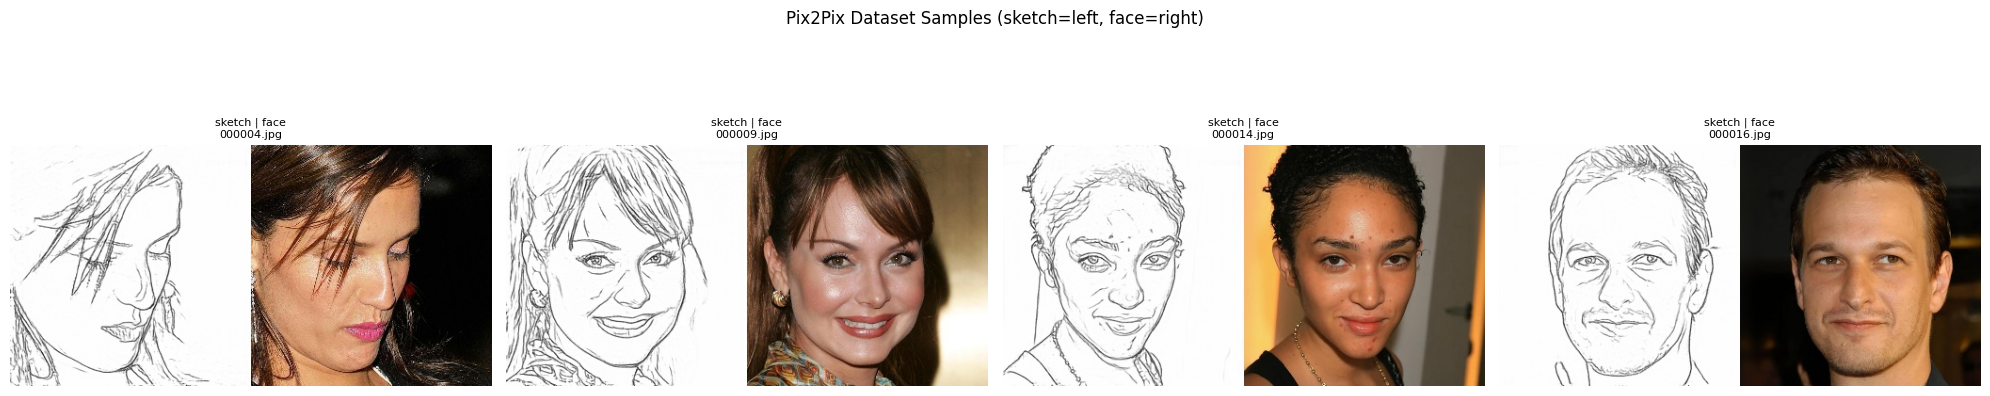

Train images: 28000
Val images:   2000


In [2]:

import matplotlib.pyplot as plt
from pathlib import Path
import cv2

samples = list((Path(DATASET_DIR) / 'train').glob('*.jpg'))[:4]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, p in zip(axes, samples):
    img = cv2.imread(str(p))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"sketch | face\n{p.name}", fontsize=8)
    ax.axis('off')
plt.suptitle("Pix2Pix Dataset Samples (sketch=left, face=right)", fontsize=12)
plt.tight_layout()
plt.show()
print(f"Train images: {len(list((Path(DATASET_DIR)/'train').glob('*.jpg')))}")
print(f"Val images:   {len(list((Path(DATASET_DIR)/'val').glob('*.jpg')))}")


## Cell 5 — Train pix2pix

~2-3 hours for 200 epochs on RTX 5880. Checkpoints saved every 50 epochs.

In [2]:

import subprocess
from tqdm import tqdm

EXP_NAME = 'sketch2face_pix2pix'

cmd = [
    'python', os.path.join(PIX2PIX_REPO, 'train.py'),
    '--dataroot',      DATASET_DIR,
    '--name',          EXP_NAME,
    '--model',         'pix2pix',
    '--direction',     'AtoB',
    '--input_nc',      '3',
    '--output_nc',     '3',
    '--continue_train',
    '--epoch_count',   '88',
    '--n_epochs',      '50',
    '--n_epochs_decay','50',
    '--batch_size',    '8',
    '--load_size',     '256',
    '--crop_size',     '256',
    '--preprocess',    'none',
    '--no_flip',
    '--save_epoch_freq','50',
    '--checkpoints_dir', CHECKPOINTS,
    '--norm',          'batch',
    '--netG',          'unet_256',
    '--lambda_L1',     '100',
    '--gan_mode',      'vanilla',
]

print('Command:', ' '.join(cmd))
print('Training started...')
print('='*60)

process = subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    cwd=PIX2PIX_REPO
)

pbar = tqdm(total=100, desc='Epoch', unit='epoch',
            bar_format='{l_bar}{bar}| {n}/{total} [{elapsed}<{remaining}]')

current_epoch = 0
for line in process.stdout:
    print(line, end='')
    if '(epoch:' in line:
        try:
            ep = int(line.split('(epoch:')[1].split(',')[0].strip())
            if ep > current_epoch:
                pbar.n = ep
                pbar.refresh()
                current_epoch = ep
        except:
            pass

pbar.close()
process.wait()
print('Done. Return code:', process.returncode)


Command: python C:\Users\rendering_lab-01\Downloads\pytorch-CycleGAN-and-pix2pix\train.py --dataroot C:\Users\rendering_lab-01\Downloads\pix2pix_dataset --name sketch2face_pix2pix --model pix2pix --direction AtoB --input_nc 3 --output_nc 3 --continue_train --epoch_count 88 --n_epochs 50 --n_epochs_decay 50 --batch_size 8 --load_size 256 --crop_size 256 --preprocess none --no_flip --save_epoch_freq 50 --checkpoints_dir C:\Users\rendering_lab-01\Downloads\pix2pix_checkpoints --norm batch --netG unet_256 --lambda_L1 100 --gan_mode vanilla
Training started...


Epoch:   0%|                                                                                          | 0/100 [00:00<?]

C:\Users\rendering_lab-01\Downloads\pytorch-CycleGAN-and-pix2pix\models\base_model.py:182: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:839.)
  errors_ret[name] = float(getattr(self, "loss_" + name))  # float(...) works for both scalar tensor and float number


Epoch:  88%|██████████████████████████████████████████████████████████████████████████▊          | 88/100 [03:04<00:25]

----------------- Options ---------------
               batch_size: 8                             	[default: 1]
                    beta1: 0.5                           
          checkpoints_dir: C:\Users\rendering_lab-01\Downloads\pix2pix_checkpoints	[default: ./checkpoints]
           continue_train: True                          	[default: False]
                crop_size: 256                           
                 dataroot: C:\Users\rendering_lab-01\Downloads\pix2pix_dataset	[default: None]
             dataset_mode: aligned                       
                direction: AtoB                          
             display_freq: 400                           
          display_winsize: 256                           
                    epoch: latest                        
              epoch_count: 88                            	[default: 1]
                 gan_mode: vanilla                       
                init_gain: 0.02                          
                

...


[Rank 0] (epoch: 98, iters: 28040, time: 0.032, data: 0.002) , G_GAN: 6.508, G_L1: 11.989, D_real: 0.002, D_fake: 0.005

learning rate 0.0000118 -> 0.0000078
End of epoch 98 / 100 	 Time Taken: 517 sec
[Rank 0] (epoch: 99, iters: 144, time: 0.044, data: 0.002) , G_GAN: 6.741, G_L1: 12.560, D_real: 0.023, D_fake: 0.003

[Rank 0] (epoch: 99, iters: 344, time: 0.031, data: 0.002) , G_GAN: 7.230, G_L1: 11.379, D_real: 0.359, D_fake: 0.001

[Rank 0] (epoch: 99, iters: 544, time: 0.033, data: 0.002) , G_GAN: 5.108, G_L1: 12.030, D_real: 0.000, D_fake: 0.018

[Rank 0] (epoch: 99, iters: 744, time: 0.029, data: 0.003) , G_GAN: 6.757, G_L1: 11.227, D_real: 0.015, D_fake: 0.004

[Rank 0] (epoch: 99, iters: 944, time: 0.044, data: 0.003) , G_GAN: 4.823, G_L1: 12.170, D_real: 0.000, D_fake: 0.025

saving the latest model (epoch 99, total_iters 310000)
[Rank 0] (epoch: 99, iters: 1144, time: 0.031, data: 0.003) , G_GAN: 5.020, G_L1: 11.988, D_real: 0.008, D_fake: 0.020

[Rank 0] (epoch: 99, iters:

Epoch: 100%|██████████████████████████████████████████████████████████████████████████████████| 100/100 [1:47:15<00:00]


saving the latest model (epoch 99, total_iters 335000)
[Rank 0] (epoch: 99, iters: 26144, time: 0.035, data: 0.001) , G_GAN: 5.380, G_L1: 11.620, D_real: 0.000, D_fake: 0.015

[Rank 0] (epoch: 99, iters: 26344, time: 0.035, data: 0.002) , G_GAN: 7.018, G_L1: 11.610, D_real: 0.001, D_fake: 0.003

[Rank 0] (epoch: 99, iters: 26544, time: 0.034, data: 0.002) , G_GAN: 5.209, G_L1: 12.651, D_real: 0.000, D_fake: 0.019

[Rank 0] (epoch: 99, iters: 26744, time: 0.032, data: 0.002) , G_GAN: 5.505, G_L1: 11.196, D_real: 0.017, D_fake: 0.011

[Rank 0] (epoch: 99, iters: 26944, time: 0.043, data: 0.002) , G_GAN: 4.151, G_L1: 10.682, D_real: 0.001, D_fake: 0.059

[Rank 0] (epoch: 99, iters: 27144, time: 0.030, data: 0.002) , G_GAN: 5.280, G_L1: 11.286, D_real: 0.008, D_fake: 0.019

[Rank 0] (epoch: 99, iters: 27344, time: 0.031, data: 0.003) , G_GAN: 5.126, G_L1: 10.325, D_real: 0.002, D_fake: 0.019

[Rank 0] (epoch: 99, iters: 27544, time: 0.035, data: 0.003) , G_GAN: 5.325, G_L1: 12.549, D_real

Epoch: 100%|██████████████████████████████████████████████████████████████████████████████████| 100/100 [1:52:36<00:00]

Done. Return code: 0


## Cell 6 — Test on val set

In [3]:

import subprocess

EXP_NAME = 'sketch2face_pix2pix'

cmd = [
    'python', os.path.join(PIX2PIX_REPO, 'test.py'),
    '--dataroot',       DATASET_DIR,
    '--name',           EXP_NAME,
    '--model',          'pix2pix',
    '--direction',      'AtoB',
    '--input_nc',       '3',
    '--output_nc',      '3',
    '--load_size',      '256',
    '--crop_size',      '256',
    '--preprocess',     'none',
    '--no_flip',
    '--phase',          'val',
    '--checkpoints_dir', CHECKPOINTS,
    '--results_dir',    RESULTS_DIR,
    '--num_test',       '50',
    '--netG',           'unet_256',
    '--norm',           'batch',
    '--epoch',          'latest',
    '--eval',
]
print('Running test...')
result = subprocess.run(cmd, capture_output=True, text=True, cwd=PIX2PIX_REPO)
print(result.stdout[-3000:])
if result.returncode != 0:
    print("STDERR:", result.stderr[-2000:])
print("Done. Return code:", result.returncode)


Running test...
                         
                    model: pix2pix                       	[default: test]
               n_layers_D: 3                             
                     name: sketch2face_pix2pix           	[default: experiment_name]
                      ndf: 64                            
                     netD: basic                         
                     netG: unet_256                      
                      ngf: 64                            
               no_dropout: False                         
                  no_flip: True                          	[default: False]
                     norm: batch                         
                 num_test: 50                            
              num_threads: 4                             
                output_nc: 3                             
                    phase: val                           	[default: test]
               preprocess: none                          	[default: re

## Cell 7 — Visualize results

Found 50 generated images


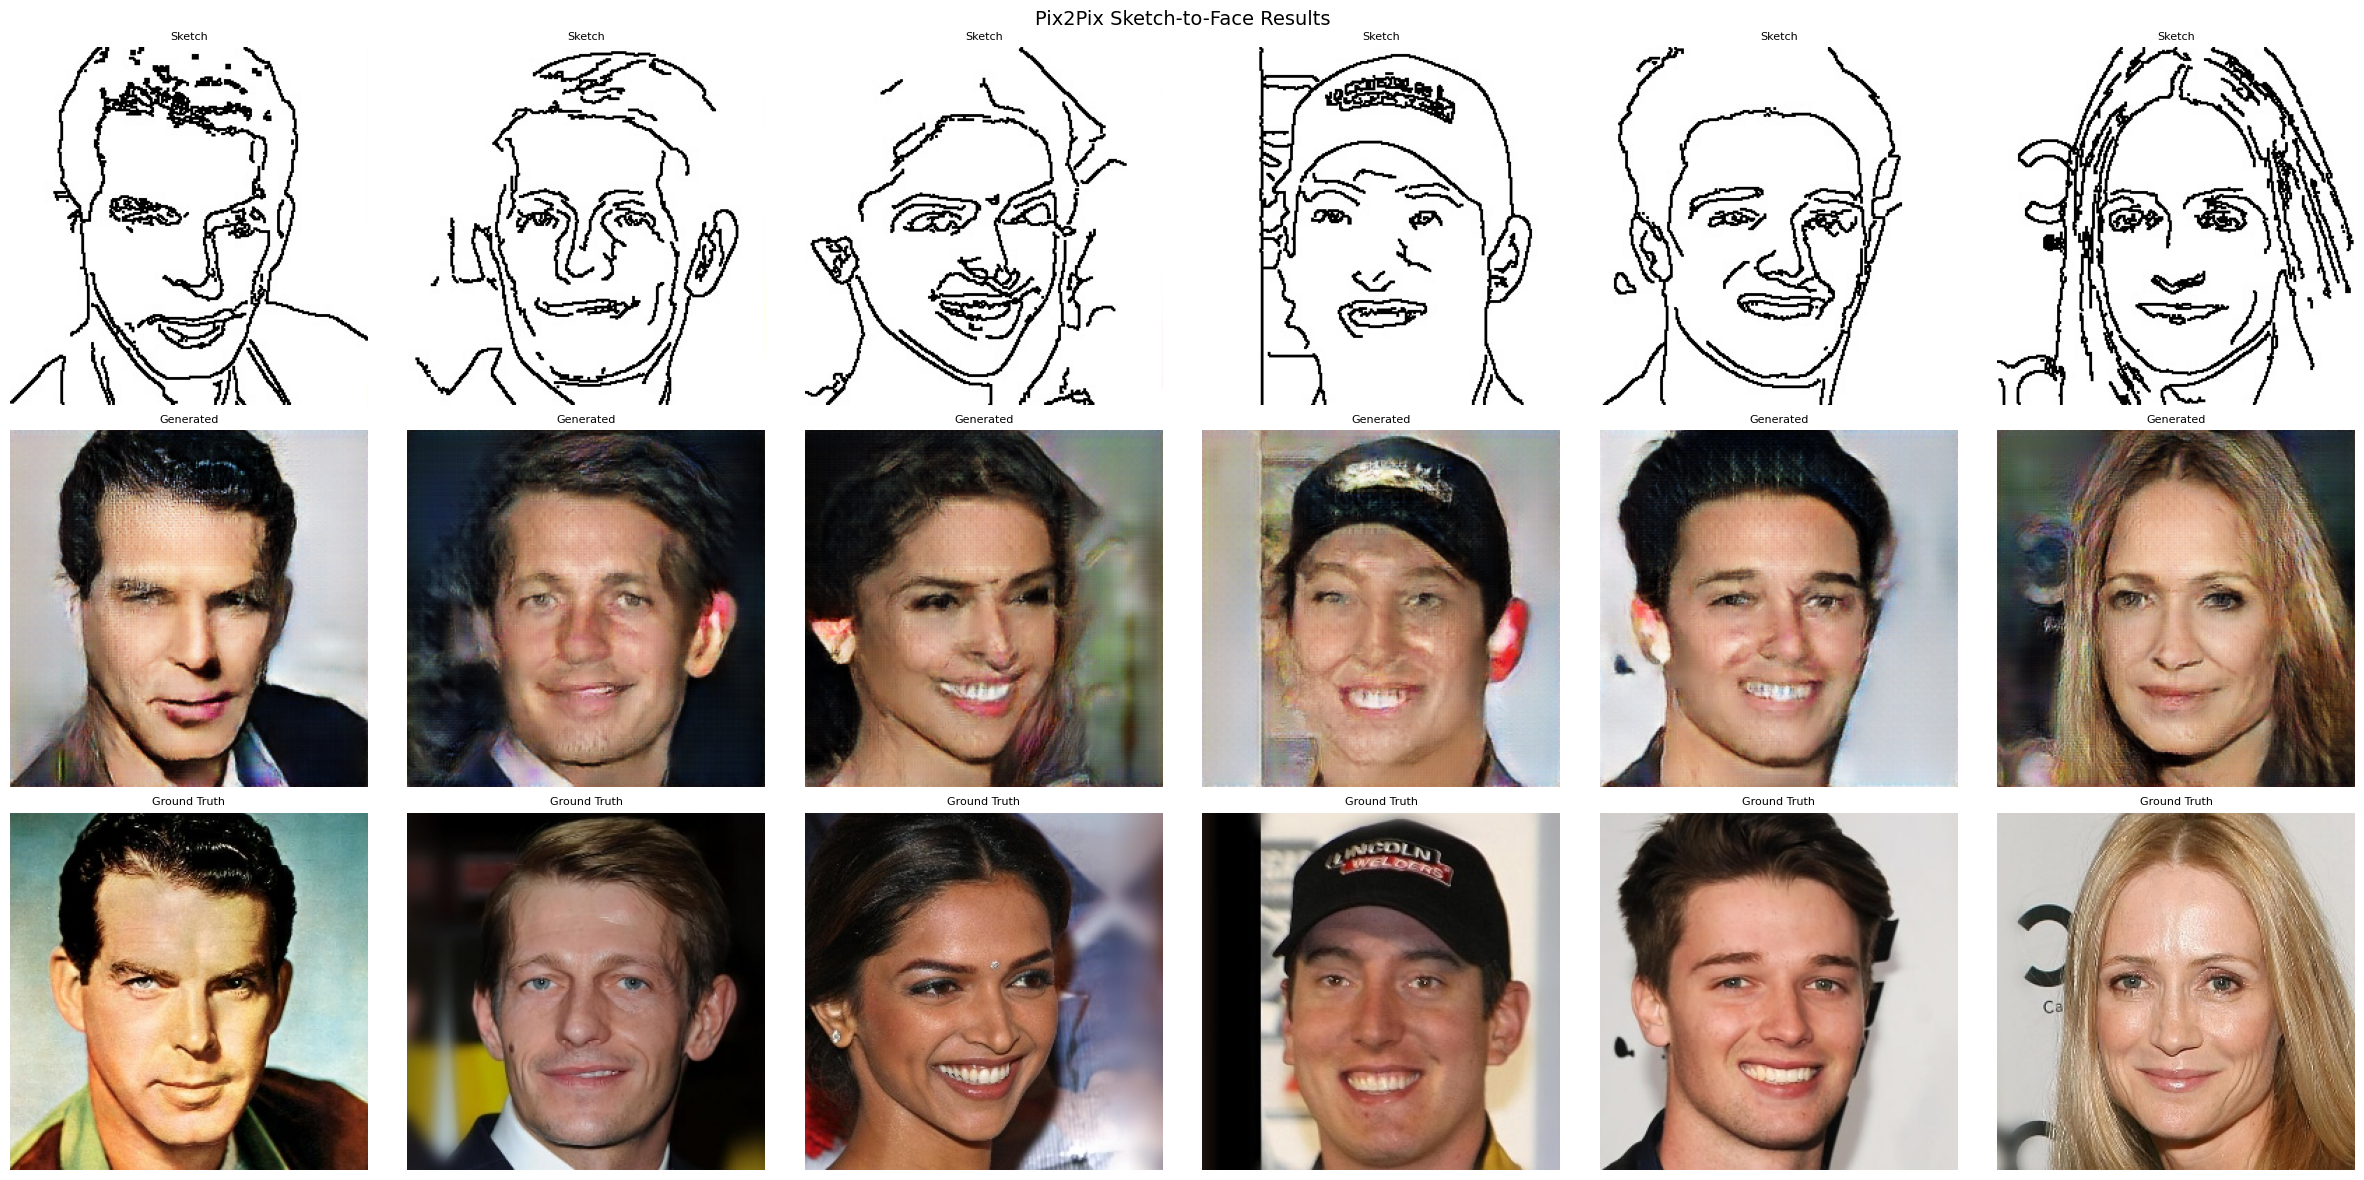

Saved to Downloads/pix2pix_results_vis.png


In [6]:

import matplotlib.pyplot as plt
import cv2
from pathlib import Path
import numpy as np

# pix2pix test saves: fake_B (generated), real_A (sketch), real_B (GT face)
results_path = Path(RESULTS_DIR) / 'sketch2face_pix2pix' / 'val_latest' / 'images'

if not results_path.exists():
    print("Results not found at:", results_path)
    print("Run Cell 6 first.")
else:
    fake_B_files = sorted(results_path.glob('*_fake_B.png'))[:6]
    print(f"Found {len(list(results_path.glob('*_fake_B.png')))} generated images")

    fig, axes = plt.subplots(3, 6, figsize=(24, 12))

    for i, fake_path in enumerate(fake_B_files):
        name     = fake_path.stem.replace('_fake_B', '')
        real_a   = results_path / f"{name}_real_A.png"
        real_b   = results_path / f"{name}_real_B.png"

        sketch = cv2.cvtColor(cv2.imread(str(real_a)), cv2.COLOR_BGR2RGB)
        gt     = cv2.cvtColor(cv2.imread(str(real_b)), cv2.COLOR_BGR2RGB)
        gen    = cv2.cvtColor(cv2.imread(str(fake_path)), cv2.COLOR_BGR2RGB)

        axes[0][i].imshow(sketch); axes[0][i].set_title(f"Sketch", fontsize=8)
        axes[1][i].imshow(gen);    axes[1][i].set_title(f"Generated", fontsize=8)
        axes[2][i].imshow(gt);     axes[2][i].set_title(f"Ground Truth", fontsize=8)

        for r in range(3): axes[r][i].axis('off')

    axes[0][0].set_ylabel("Sketch",       rotation=0, labelpad=60, va='center', fontsize=10)
    axes[1][0].set_ylabel("pix2pix out",  rotation=0, labelpad=60, va='center', fontsize=10)
    axes[2][0].set_ylabel("Ground Truth", rotation=0, labelpad=60, va='center', fontsize=10)

    plt.suptitle("Pix2Pix Sketch-to-Face Results", fontsize=14)
    plt.tight_layout()
    plt.savefig(r'C:\Users\rendering_lab-01\Downloads\pix2pix_results_vis.png',
                dpi=100, bbox_inches='tight')
    plt.show()
    print("Saved to Downloads/pix2pix_results_vis.png")


## Cell 8 — Single image inference test (for app integration)

Generator loaded.


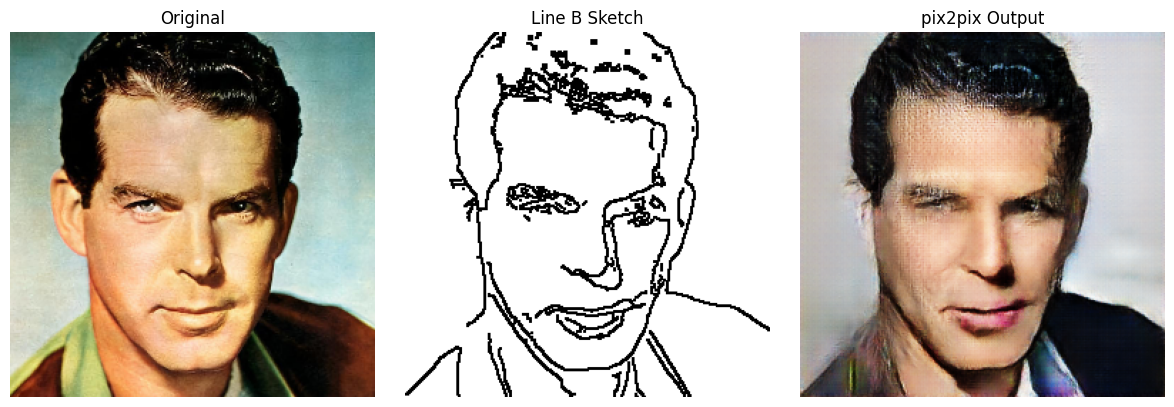

Done.


In [12]:
import torch
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import sys
from torchvision import transforms

sys.path.insert(0, PIX2PIX_REPO)

# ── Load generator directly ───────────────────────────────────────
from models.networks import define_G

device = 'cuda' if torch.cuda.is_available() else 'cpu'

netG = define_G(
    input_nc=3, output_nc=3, ngf=64,
    netG='unet_256', norm='batch',
    use_dropout=False, init_type='normal',
    init_gain=0.02
)

ckpt_path = os.path.join(CHECKPOINTS, 'sketch2face_pix2pix', 'latest_net_G.pth')
state = torch.load(ckpt_path, map_location=device)
netG.load_state_dict(state)
netG = netG.to(device).eval()
print("Generator loaded.")

# ── Sketch function ───────────────────────────────────────────────
def make_lineb_sketch(bgr):
    gray   = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    smooth = cv2.bilateralFilter(gray, 9, 75, 75)
    edges  = cv2.Canny(smooth, 20, 80)
    kernel = np.ones((2,2), np.uint8)
    thick  = cv2.dilate(edges, kernel, iterations=1)
    return 255 - thick

tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

def sketch_to_face(img_path):
    bgr        = cv2.imread(img_path)
    bgr_r      = cv2.resize(bgr, (256,256))
    sketch     = make_lineb_sketch(bgr_r)
    sketch_bgr = cv2.cvtColor(sketch, cv2.COLOR_GRAY2BGR)
    sketch_rgb = cv2.cvtColor(sketch_bgr, cv2.COLOR_BGR2RGB)
    t          = tf(Image.fromarray(sketch_rgb)).unsqueeze(0).to(device)
    with torch.no_grad():
        out = netG(t)[0].cpu().float()
    out = ((out + 1)/2).clamp(0,1)
    out = (out.permute(1,2,0).numpy()*255).astype('uint8')
    return cv2.cvtColor(bgr_r, cv2.COLOR_BGR2RGB), sketch, out

# ── Test ──────────────────────────────────────────────────────────
orig, sketch, result = sketch_to_face(
    r'C:\Users\rendering_lab-01\Downloads\celeba_hq\val\male\000080.jpg'
)

fig, axes = plt.subplots(1, 3, figsize=(12,4))
axes[0].imshow(orig);              axes[0].set_title('Original')
axes[1].imshow(sketch, cmap='gray'); axes[1].set_title('Line B Sketch')
axes[2].imshow(result);            axes[2].set_title('pix2pix Output')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()
print("Done.")